In [13]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
from matplotlib.ticker import PercentFormatter

# Set cwd to project root (works from any run location)
def get_project_root():
    for p in [Path.cwd()] + list(Path.cwd().resolve().parents):
        if (p / 'src').exists() and (p / 'results').exists():
            return p
    return Path.cwd()

project_root = get_project_root()
print(project_root)
os.chdir(project_root)

COLORS = {
    'jpeg': 'tab:blue',
    'turbo_ddcm': 'tab:orange',
    'robust_turbo_ddcm': 'tab:green',
    'ddcm': 'tab:red',
    'bpg': 'tab:purple',
    'robustB10': 'tab:brown',
    'diffc': 'tab:pink',
    'illm': 'tab:gray',
    'stable_codec': 'tab:cyan'
}

MARKERS = {
    'jpeg': 'o',
    'turbo_ddcm': 's',
    'robust_turbo_ddcm': 'D',
    'ddcm': '^',
    'bpg': 'v',
    'robustB10': 'P',
    'diffc': 'X',
    'illm': '*',
    'stable_codec': 'h'
}

LABELS = {'jpeg': 'JPEG', 'turbo_ddcm': 'Turbo-DDCM', 'robust_turbo_ddcm': 'Robust Turbo-DDCM', 'ddcm': 'DDCM', 'bpg': 'BPG', 'robustB10' : 'Robust Turbo-DDCM B=10', 'diffc' : 'DiffC', 'illm' : 'ILLM', 'VAE Bound' : 'VAE Bound', 'stable_codec' : 'StableCodec'}

SUBTITLES = {'psnr' : 'PSNR \\uparrow', 'lpips' : 'LPIPS \\downarrow', 'fid' : 'FID (log scale) \\downarrow',
             'niqe' : 'NIQE \\downarrow', 'failed_ind' : '\% Corrupted Files \\downarrow'}
DATASET_TITLES = {
    "dataset_Kodak24" : r"$\mathrm{Kodak24}_{512}$",
    "DIV2K_valid_HR_512" : r"$\mathrm{DIV2K}_{512}$",
}

DATASET_LEN = {
    "dataset_Kodak24" : 24,
    "DIV2K_valid_HR_512" : 100
}

VAE = {'dataset_Kodak24' : [26.43, 0.071, 20.271],
       'DIV2K_valid_HR_512' : [24.879, 0.0756, 23.404]}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 20,     # title size
    'axes.labelsize': 18,     # x and y label size
    'xtick.labelsize': 18,    # x tick size
    'ytick.labelsize': 18,    # y tick size
    'legend.fontsize': 18     # legend size
})

def tex_label(text: str) -> str:
    """Wrap plain text into LaTeX mathrm with escaped spaces."""
    return r"$\mathrm{" + text.replace(" ", r"\ ") + "}$"

/home/galkesten/Diffusion-Compression-Editing-Attacks


In [14]:
# config
args = {}
args['methods'] = ['jpeg', 'bpg', 'illm', 'stable_codec', 'diffc', 'ddcm',  'turbo_ddcm', 'robust_turbo_ddcm']
args['datasets'] = ['dataset_Kodak24', 'DIV2K_valid_HR_512']
args['ber_min'] = 1e-6
args['ber_max'] = 1

NUM_TRIALS = 10
NUM_BER_VALUES = 6

In [15]:
results_df = pd.DataFrame()
for method in args['methods']:
    for dataset in args['datasets']:
        base = f'results/noisy_channel/{method}/{dataset}'

        current_df = pd.read_csv(f'{base}/noisy_channel_{method}.csv')

        # make sure all results are here
        # print(current_df.groupby(['ber', 'trial'])['image_file'].count().reset_index()['image_file'].unique())
        if current_df.groupby(['ber', 'trial'])['image_file'].count().reset_index()['image_file'].unique() != DATASET_LEN[dataset]:
            dataset_len = DATASET_LEN[dataset]
            current_df_len = current_df.groupby(['ber', 'trial'])['image_file'].count().reset_index()['image_file'].unique()
            print(f"ERROR DATA: {method} {dataset}- {current_df_len} {dataset_len}")

        if len(current_df) != DATASET_LEN[dataset] * (NUM_BER_VALUES * NUM_TRIALS + 1):
            current_df_len = len(current_df)
            compare_value = DATASET_LEN[dataset] * (NUM_BER_VALUES * NUM_TRIALS + 1)
            print(f"ERROR DATA 2: {method} {dataset}- {current_df_len} {compare_value}")

        current_df_fid = pd.read_csv(f'{base}/fid_{method}.csv')
        if len(current_df_fid) != NUM_BER_VALUES * NUM_TRIALS:
            print(f"ERROR FID: {method} {dataset}")

        current_df = current_df.merge(current_df_fid, on=['ber', 'trial'], validate='m:1')

        assert (~((current_df['error'].notna()) & (current_df['psnr'].notna()))).all()
        current_df['failed_ind'] = current_df['error'].notna()

        current_df['dataset'] = dataset
        current_df['method'] = method
        results_df = pd.concat([results_df, current_df])

results_df = results_df.reset_index()
results_df = results_df[results_df['ber'].between(args['ber_min'], args['ber_max'])]
# results_df[['method', 'dataset']].drop_duplicates()

ERROR DATA: diffc dataset_Kodak24- [23] 24
ERROR DATA 2: diffc dataset_Kodak24- 1403 1464


/tmp/ipykernel_3173501/179750707.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


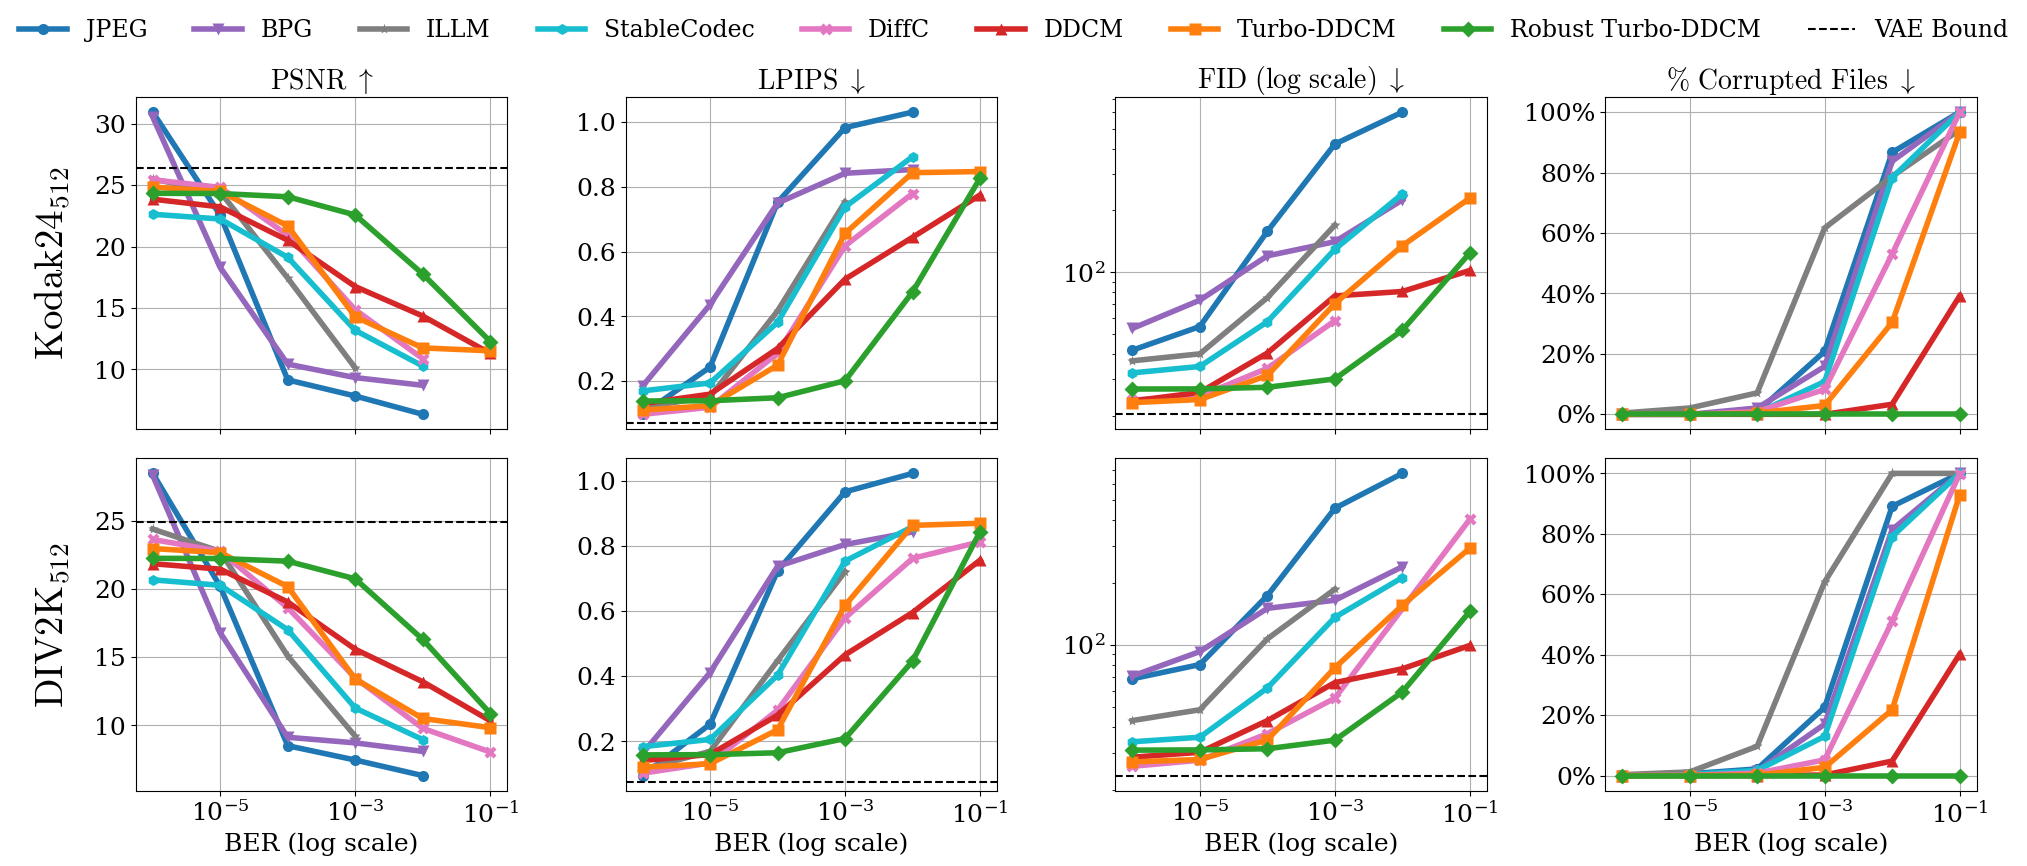

In [16]:
x_field = 'ber'
hue_field_name = 'method'
metrics_to_plot = ["psnr", "lpips", "fid", "failed_ind"]
datasets = args['datasets']
n_rows = len(datasets)
n_cols = len(metrics_to_plot)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4.2 * n_rows),
                         sharex=True, constrained_layout=True)

if n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

legend_ax = None
for row_idx, dataset in enumerate(datasets):
    df_subset = results_df[results_df["dataset"] == dataset]
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx][col_idx]
        sns.lineplot(
            data=df_subset,
            x=x_field,
            y=metric,
            hue=hue_field_name,
            marker='o',
            errorbar=None, # (ci_pi, confidence_level),
            ax=ax,
            style=hue_field_name,
            markers=MARKERS,
            dashes=False,
            palette=COLORS,
            linewidth=4,
            markersize=8,
            markeredgecolor="none"
        )

        if legend_ax is None:
            legend_ax = ax
        ax.get_legend().remove()

        ax.set_xscale('log')
        ax.grid(True)
        ax.set_ylabel(None)
        ax.set_xlabel('BER (log scale)')

        # Column titles on top row
        if row_idx == 0:
            ax.set_title(tex_label(SUBTITLES[metric]))
        if col_idx == 3:
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        if col_idx < 3:
            ax.axhline(y=VAE[dataset][col_idx], color='black', linestyle='--', label='VAE Bound')
        if col_idx == 2:
            ax.set_yscale('log')

    axes[row_idx][0].text(-0.17, 0.5, DATASET_TITLES[dataset], va="center", ha="right",
                          fontsize=28, rotation=90, transform=axes[row_idx][0].transAxes)

handles, labels = legend_ax.get_legend_handles_labels()
labels = [LABELS[label] for label in labels]
desired_order = [LABELS[method] for method in (args['methods'] + ['VAE Bound'])]
order = [labels.index(l) for l in desired_order]

handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

fig.legend(
    handles, labels,
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    fontsize = 17
)

plt.tight_layout()
# plt.show()

output_dir = 'results/plots'
output_path = os.path.join(output_dir, 'quant_main.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight')


In [ ]:
results_df[(results_df["method"] == "diffc") &(results_df["ber"] == 0.001) & (results_df["dataset"] == "DIV2K_valid_HR_512")& (results_df["trial"] == 1)]

,index,image_file,ber,trial,num_bit_flips,bpp,psnr,niqe,lpips,error,fid,failed_ind,dataset,method
34240,3100,0801.png,0.001,1,38,0.138855,12.366889,2.393359,0.617060,NaN,NaN,False,DIV2K_valid_HR_512,diffc
34241,3101,0802.png,0.001,1,35,0.110474,NaN,NaN,NaN,Error -3 while decompressing data: incorrect d...,NaN,True,DIV2K_valid_HR_512,diffc
34242,3102,0803.png,0.001,1,29,0.103394,13.257405,3.230779,0.693811,NaN,NaN,False,DIV2K_valid_HR_512,diffc
34243,3103,0804.png,0.001,1,30,0.121246,12.009975,2.494375,0.633741,NaN,NaN,False,DIV2K_valid_HR_512,diffc
34244,3104,0805.png,0.001,1,25,0.128845,11.528662,2.126022,0.698080,NaN,NaN,False,DIV2K_valid_HR_512,diffc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34335,3195,0896.png,0.001,1,29,0.089752,NaN,NaN,NaN,list index out of range,NaN,True,DIV2K_valid_HR_512,diffc
34336,3196,0897.png,0.001,1,25,0.100220,9.980030,2.486028,0.863890,NaN,NaN,False,DIV2K_valid_HR_512,diffc
34337,3197,0898.png,0.001,1,26,0.095886,18.634025,5.495124,0.175147,NaN,NaN,False,DIV2K_valid_HR_512,diffc
34338,3198,0899.png,0.001,1,28,0.099091,12.375182,4.363489,0.662517,NaN,NaN,False,DIV2K_valid_HR_512,diffc


In [ ]:
import numpy as np

BER_VALUES = [1e-4, 1e-3]  
TABLE_METRICS = ['psnr', 'lpips', 'fid', 'failed_ind']
TABLE_METRIC_LABELS = ['PSNR', 'LPIPS', 'FID', '% Corrupted']
# LaTeX column names with arrow indicators (↑ higher better, ↓ lower better)
LATEX_COLUMN_NAMES = {
    'PSNR': r'PSNR $\uparrow$',
    'LPIPS': r'LPIPS $\downarrow$',
    'FID': r'FID $\downarrow$',
    '% Corrupted': r'\% Corrupted Files $\downarrow$'
}
METHOD_ORDER = args['methods']  
METHOD_DISPLAY = [LABELS[m] for m in METHOD_ORDER]

def build_table_for_subset(df_sub, metric_labels=TABLE_METRIC_LABELS):
    # Aggregate per metric, explicitly ignoring NaN (dropna) so they don't affect results
    stats_image = df_sub.groupby(['method', 'ber']).agg(
        psnr_mean=('psnr', lambda x: x.dropna().mean()),
        psnr_std=('psnr', lambda x: x.dropna().std()),
        lpips_mean=('lpips', lambda x: x.dropna().mean()),
        lpips_std=('lpips', lambda x: x.dropna().std()),
        failed_ind_mean=('failed_ind', 'mean')  # proportion True (corrupted) / total
    ).reset_index()

    fid_per_trial = df_sub.groupby(['method', 'ber', 'trial'])['fid'].first().reset_index()
    fid_stats = fid_per_trial.groupby(['method', 'ber']).agg(
        fid_mean=('fid', lambda x: x.dropna().mean()),
        fid_std=('fid', lambda x: x.dropna().std())
    ).reset_index()

    stats = stats_image.merge(fid_stats, on=['method', 'ber'])

    table_data = []
    for method in METHOD_ORDER:
        row = []
        for metric in TABLE_METRICS:
            m_row = stats[stats['method'] == method]
            if len(m_row) == 0:
                row.append('—')
                continue
            mu = m_row[f'{metric}_mean'].values[0]
            if np.isnan(mu):
                row.append('—')
                continue
            if metric == 'failed_ind':
                # Percentage of corrupted (True) out of all images
                row.append(f'{100*mu:.2f}')
                continue
            sig = m_row[f'{metric}_std'].values[0]
            if np.isnan(sig):
                # Not enough valid samples for std; show mean only
                if metric == 'fid':
                    row.append(f'{mu:.2f}')
                elif metric == 'psnr':
                    row.append(f'{mu:.2f}')
                elif metric == 'lpips':
                    row.append(f'{mu:.4f}')
                else:
                    row.append(f'{mu:.3f}')
            else:
                if metric == 'fid':
                    row.append(f'{mu:.2f} ± {sig:.2f}')
                elif metric == 'psnr':
                    row.append(f'{mu:.2f} ± {sig:.2f}')
                elif metric == 'lpips':
                    row.append(f'{mu:.4f} ± {sig:.4f}')
                else:
                    row.append(f'{mu:.3f} ± {sig:.3f}')
        table_data.append(row)

    table_df = pd.DataFrame(table_data, index=METHOD_DISPLAY, columns=metric_labels)
    return table_df

# Generate: 4 CSV tables (per dataset×BER) + 2 LaTeX tables (one per BER, both datasets combined)
output_dir = 'results/plots'
os.makedirs(output_dir, exist_ok=True)

for dataset in args['datasets']:
    df_ds = results_df[results_df['dataset'] == dataset]
    for ber in BER_VALUES:
        df_ber = df_ds[np.isclose(df_ds['ber'], ber)]
        if len(df_ber) == 0:
            print(f"No data for {dataset} @ BER={ber}")
            continue
        tbl = build_table_for_subset(df_ber)
        try:
            display(tbl)
        except NameError:
            pass
        ber_str = f"1e{int(np.log10(ber))}"
        ds_short = 'Kodak24' if 'Kodak' in dataset else 'DIV2K'
        tbl.to_csv(os.path.join(output_dir, f'table_{ds_short}_BER_{ber_str}.csv'))

# Combined LaTeX: one table per BER, with Dataset1 (all methods) then Dataset2 (all methods)
for ber in BER_VALUES:
    tbls = []
    for dataset in args['datasets']:
        df_ds = results_df[results_df['dataset'] == dataset]
        df_ber = df_ds[np.isclose(df_ds['ber'], ber)]
        if len(df_ber) == 0:
            continue
        tbl = build_table_for_subset(df_ber)
        ds_short = 'Kodak24' if 'Kodak' in dataset else 'DIV2K'
        tbl = tbl.reset_index().rename(columns={'index': 'Method'})
        tbl.insert(0, 'Dataset', ds_short)
        tbls.append(tbl)
    if tbls:
        combined = pd.concat(tbls, ignore_index=True)
        ber_str = f"1e{int(np.log10(ber))}"
        latex_path = os.path.join(output_dir, f'table_combined_BER_{ber_str}.tex')
        combined_latex = combined.rename(columns=LATEX_COLUMN_NAMES)
        combined_latex.to_latex(latex_path, index=False, escape=False)


,PSNR,LPIPS,FID,% Corrupted
JPEG,9.15 ± 2.54,0.7525 ± 0.1681,157.98 ± 24.56,0.83
BPG,10.43 ± 2.00,0.7502 ± 0.1083,120.03 ± 4.26,2.08
ILLM,17.43 ± 5.45,0.4167 ± 0.2196,75.05 ± 5.25,7.08
StableCodec,19.12 ± 4.81,0.3814 ± 0.2811,57.30 ± 6.82,0.42
DiffC,20.92 ± 4.18,0.2858 ± 0.1797,33.95 ± 1.74,0.87
DDCM,20.52 ± 3.70,0.3007 ± 0.1757,40.31 ± 6.17,0.00
Turbo-DDCM,21.68 ± 4.18,0.2492 ± 0.1805,31.35 ± 2.53,0.42
Robust Turbo-DDCM,24.05 ± 2.90,0.1485 ± 0.0656,27.46 ± 0.19,0.00


,PSNR,LPIPS,FID,% Corrupted
JPEG,7.84 ± 2.14,0.9834 ± 0.0794,420.95 ± 38.97,20.83
BPG,9.33 ± 1.56,0.8423 ± 0.0824,140.70 ± 6.28,15.83
ILLM,10.12 ± 2.78,0.7537 ± 0.1021,169.38 ± 9.16,61.67
StableCodec,13.18 ± 3.62,0.7383 ± 0.2138,129.21 ± 15.79,10.83
DiffC,14.85 ± 3.00,0.6179 ± 0.1471,57.94 ± 3.53,8.26
DDCM,16.74 ± 2.69,0.5150 ± 0.1564,76.57 ± 7.09,0.00
Turbo-DDCM,14.28 ± 3.17,0.6564 ± 0.1736,70.22 ± 4.81,2.92
Robust Turbo-DDCM,22.57 ± 2.58,0.2011 ± 0.0756,30.15 ± 0.57,0.00


,PSNR,LPIPS,FID,% Corrupted
JPEG,8.52 ± 2.48,0.7227 ± 0.1736,173.06 ± 7.18,2.20
BPG,9.13 ± 1.84,0.7368 ± 0.1222,150.19 ± 2.27,1.50
ILLM,15.08 ± 5.11,0.4472 ± 0.2003,106.93 ± 4.87,9.70
StableCodec,17.01 ± 4.71,0.4030 ± 0.2794,61.96 ± 5.10,1.70
DiffC,18.62 ± 4.14,0.2956 ± 0.1788,37.27 ± 1.29,0.80
DDCM,19.04 ± 3.56,0.2803 ± 0.1687,43.12 ± 1.64,0.00
Turbo-DDCM,20.17 ± 4.12,0.2354 ± 0.1674,34.78 ± 1.59,0.20
Robust Turbo-DDCM,22.03 ± 3.07,0.1650 ± 0.0816,31.54 ± 0.19,0.00


,PSNR,LPIPS,FID,% Corrupted
JPEG,7.47 ± 2.64,0.9656 ± 0.0951,456.82 ± 35.16,22.60
BPG,8.72 ± 1.77,0.8041 ± 0.0963,164.36 ± 2.57,17.00
ILLM,9.21 ± 2.59,0.7210 ± 0.1268,185.79 ± 7.23,64.10
StableCodec,11.28 ± 3.17,0.7531 ± 0.2125,135.96 ± 4.88,13.00
DiffC,13.48 ± 2.83,0.5788 ± 0.1532,55.33,5.20
DDCM,15.58 ± 2.67,0.4654 ± 0.1569,65.78 ± 2.94,0.20
Turbo-DDCM,13.41 ± 3.13,0.6171 ± 0.1807,77.59 ± 3.36,2.70
Robust Turbo-DDCM,20.74 ± 2.69,0.2087 ± 0.0926,34.71 ± 0.40,0.00


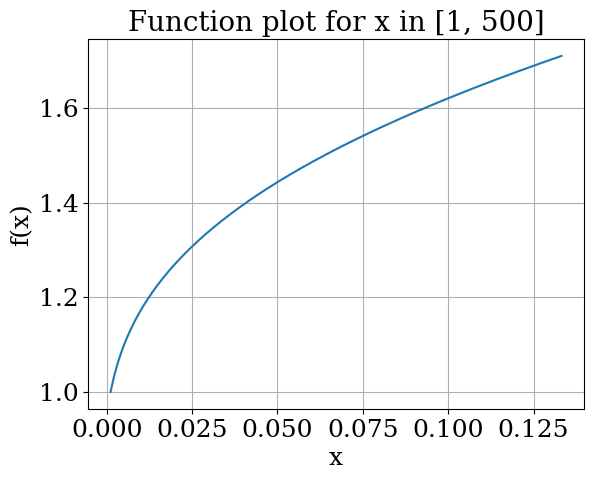

In [17]:
import numpy as np
import matplotlib.pyplot as plt

K = 16384

def f(x):
    numerator = np.log2(K) * x + x
    denominator = math.log2(math.comb(K, x)) + x
    return numerator / denominator

def bpp(x):
    return 20*(math.log2(math.comb(K, x)) + x) / (512**2)

# x range (exclude 0 because denominator becomes 0)
x_vals = np.arange(1, 200)
y_vals = [f(x) for x in x_vals]
x_vals = [bpp(x) for x in x_vals]

# Plot
plt.figure()
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.title("Function plot for x in [1, 500]")
plt.show()